# Digital Signal Processing Training Program 

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Dev by:
-   Elmer Pimentel Farias


# Analog-to-Digital and Digital-to-Analog Conversors

## Introduction

In modern electronic systems, Analog-to-Digital Converters (ADCs) and Digital-to-Analog Converters (DACs) serve as the essential interface between the analog physical world and digital signal processing systems. This notebook explores the critical stages of this conversion process: **Sampling**, **Holding**, **Quantization**, and **Encoding**.

The conversion process begins with sampling, where a continuous signal is measured periodically to create discrete values in time. Following this, quantization maps these continuous amplitude values to a finite set of $L = 2^N$ levels, where $N$ is the number of bits. This process introduces an inherent quantization error ($n_q$), which can be modeled as uniform noise.

### 1. Quantization Step ($\Delta$)

The resolution of the quantizer, or the distance between two adjacent levels, is determined by the dynamic range and the number of bits ($N$):

$$\Delta = \frac{V_{max} - V_{min}}{2^N}$$


### 2. Quantization Noise Power ($P_q$)

Under the assumption that the error is uniformly distributed between $[-\frac{\Delta}{2}, \frac{\Delta}{2}]$, the average power of the quantization noise is given by its variance:

$$P_q = \sigma_{n_q}^2 = \frac{\Delta^2}{12}$$

### 3. Ideal Signal-to-Quantization-Noise Ratio (SQNR)

For an ideal $N$-bit ADC excited by a full-scale sine wave, the SQNR in decibels is expressed as:

$$SQNR_{ideal} = 6.02N + 1.76 \text{ [dB]}$$


* The 6,02 term represents the 6 dB gain in SNR for every additional bit.


* The 1,72 term is associated with the RMS power of a sinusoid.



### 4. Effective Number of Bits (ENOB)

In real-world scenarios where distortion and non-ideal noise are present, we measure the $SNR_{real}$ to calculate the effective resolution of the converter:


$$ENOB = \frac{SNR_{real} - 1.76}{6.02}$$


## Project Objectives

We will develop a Python environment to:

* **Simulate Sampling and Reconstruction:** Model the sampling of a square wave and its reconstruction via Zero-Order Hold (ZOH).


* **Implement Uniform Quantization:** Create a function to map analog values to discrete levels and calculate the resulting error $n_q = V - V_q$ .


* **Calculate SNR and ENOB:** Compute the power of the original signal versus the noise to evaluate if our simulated ADC meets its theoretical bit depth.


* **Spectral Analysis:** Use Fast Fourier Transforms (FFT) to generate spectrum graphs and identify the harmonic distortions introduced by quantization.



### 1- Imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz
from scipy import signal
from numba import njit
from scipy.linalg import toeplitz, inv
import pandas as pd
import numpy as np
import time



### 1. Signal and Time Preparation

* **Time Axis Reconstruction**: The function first recreates the time axis of the continuous signal based on its length and its original analog frequency (`fs_analog`).
* **Noise Injection**: It optionally adds Additive White Gaussian Noise (AWGN) to simulate real-world thermal interference or imperfections before the conversion process begins.

### 2. Sampling (Amostragem)

* **Periodic Measurement**: The continuous analog signal is measured periodically, producing discrete values in time according to a specified sampling rate.


* **Downsampling**: The code calculates a `step` ratio between the original analog frequency (`fs_analog`) and the desired ADC sampling rate (`fs_sample`) to extract the precise discrete samples from the input array.

### 3. Quantization (Quantização)

This step ensures the continuous amplitude values of the sampled signal are represented by a finite set of predefined levels.

* **Number of Levels ($L$)**: The total number of quantization levels is calculated as $L = 2^N$, where $N$ represents the number of bits of the ADC.


* **Quantization Step ($\Delta$)**: The code calculates the quantization step, which is the uniform distance between each level. The formula used is $\Delta = \frac{V_{max} - V_{min}}{2^N}$.


* **Index Mapping & Overload Prevention**: The sampled voltage is divided by the step $\Delta$ to find its corresponding integer index $k$. To prevent signal overload or saturation, the code clips this index so it does not exceed the maximum physical limits of the ADC.


* **Reconstruction Level ($V_q$)**: The function uses a mid-rise uniform quantizer to calculate the final quantized voltage level for each sample. The mathematical formula applied is $V_q(k) = V_{min} + (k + \frac{1}{2})\Delta$.



### 4. Quantization Noise (Erro de quantização)

* **Error Calculation**: The code calculates the quantization error, which is defined as the difference between the actual sampled input and the quantized output: $n_q = V - V_q$.


* **Inherent Flaw**: This error is inherent to the quantization process and acts as a form of noise added to the digital signal.



### 5. Encoding (Codificação)

* **Binary Mapping**: The quantized levels (represented by the integer index $k$) are then mapped to binary codes.


* **Formatting**: The code converts the indices into binary strings, padding them with leading zeros to ensure every output string exactly matches the specified number of `bits` (e.g., a 3-bit ADC will output '000' for $k=0$ and '111' for $k=7$).



### 6. SNR and ENOB Calculation

* **Power Calculation**: The function computes the average power (mean square) of both the sampled signal ($P_{signal}$) and the quantization noise ($P_{noise}$).
* **Signal-to-Noise Ratio (SNR)**: It calculates the actual Signal-to-Noise Ratio ($SNR_{real}$) in decibels.


* **Effective Number of Bits (ENOB)**: Finally, it calculates the ENOB, a metric that expresses the effective resolution of the ADC by taking into account all sources of noise and distortion present in the real device. The mathematical definition of ENOB used in the code is $ENOB = \frac{SNR_{real} - 1.76}{6.02}$.

In [735]:
def adc_simulation(x_analog, fs_analog, fs_sample, bits, v_min, v_max, noise_std=0.0):
    """
    Simulates a complete Analog-to-Digital Converter (ADC), including noise, 
    sampling, quantization, and encoding (binary output).
    
    Parameters:
    x_analog  : Array of the input analog signal.
    fs_analog : Original sampling frequency of the "analog" signal (in Hz).
    fs_sample : Sampling rate of the ADC (in Hz).
    bits      : ADC resolution in number of bits (N).
    v_min     : Minimum voltage of the input dynamic range (in Volts).
    v_max     : Maximum voltage of the input dynamic range (in Volts).
    noise_std : Standard deviation of the Gaussian noise added to the signal.
    
    Returns:
    t_sampled          : Time axis of the samples.
    x_sampled          : Exact values of the samples.
    x_quantized        : Quantized values (voltage levels).
    quantization_noise : The error introduced by quantization.
    binary_output      : List of binary strings representing the digital output.
    """
    
    # 1. SIGNAL AND TIME PREPARATION
    
    # We recreate the time axis of the continuous signal based on its length
    # and its original generation frequency.
    num_samples = len(x_analog)
    t_final = (num_samples - 1) / fs_analog
    t_analog = np.linspace(0, t_final, num_samples)
    #t_analog = np.arange(len(x_analog)) / fs_analog
    
    # Additive White Gaussian Noise (AWGN) Injection
    # Simulates thermal imperfections or real-world interference in the input signal.
    
    if noise_std > 0:
        noise = np.random.normal(0, noise_std, len(x_analog))
        x_noisy = x_analog + noise
    else:
        x_noisy = x_analog
        
    # 2. SAMPLING
    # The continuous analog signal is measured periodically.
    # We calculate the required "step" in the array to extract samples 
    # exactly at the desired fs_sample frequency.

    step = max(1, int(fs_analog / fs_sample))
    t_sampled = t_analog[::step]
    x_sampled = x_noisy[::step]
    
    # 3. QUANTIZE
    # The continuous amplitude values are represented by a finite set of predefined levels
    
    # Total number of quantization levels (L = 2^N)[cite: 64].
    L = 2**bits 

    # Quantization step (Delta), which is the distance between each level[cite: 67].
    # Formula: Delta = (V_max - V_min) / 2^N[cite: 138].

    delta = (v_max - v_min) / L 
    
    # Mapping the sample value to the corresponding level index 'k'.
    # We use np.floor to find which "step" the sample fits into.

    k = np.floor((x_sampled - v_min) / delta)

    # Overload (Saturation) Prevention.
    # We ensure that the index 'k' does not exceed the physical limits of the ADC (0 to L-1).

    k = np.clip(k, 0, L - 1) 
    
    # Calculation of the reconstruction level (V_q) for a mid-rise uniform quantizer.
    # The exact formula is V_q(k) = V_min + (k + 0.5) * Delta

    x_quantized = v_min + (k + 0.5) * delta
    
    # 4. QUANTIZATION NOISE
    quantization_noise = x_sampled - x_quantized
    
    # 5. ENCODE (BINARY OUTPUT)
    # The quantized levels are mapped to binary codes.
    # We convert the index 'k' (float array) to integers.
    k_int = k.astype(int)
    
    # Format each integer into a binary string padded with zeros to match 'bits' length.
    # E.g., for bits=3: k=0 -> '000', k=7 -> '111'.
    binary_output = [format(val, f'0{bits}b') for val in k_int]

    # 6. SNR AND ENOB CALCULATION
   # Calculate the average power (mean square) of the sampled signal and the quantization noise
    P_signal = np.mean(x_sampled**2)
    P_noise = np.mean(quantization_noise**2)
    
    # Prevents division by zero if the noise is perfectly zero (extreme theoretical scenario)
    if P_noise == 0:
        snr_db = float('inf')
        enob = float('inf')
    else:
        # Actual Signal-to-Noise Ratio (SNR) in dB
        snr_db = 10 * np.log10(P_signal / P_noise)
        
        # Effective Number of Bits (ENOB) calculation
        # Formula: ENOB = (SNR_real - 1.76) / 6.02 (As defined in the course material)
        enob = (snr_db - 1.76) / 6.02
        
    return t_sampled, x_sampled, x_quantized, quantization_noise, binary_output, snr_db, enob

Mean results over 10 executions with noise:
-----------------------------------
ADC Resolution (3 bits) - Mean of 10 runs
SNR Real: 17.36 dB
ENOB Calculate: 2.59 bits
-----------------------------------
|   Time [s] |   Real Sample [V] |   Quantized [V] |   Quantization Noise [V] |   Binary Code |
|-----------:|------------------:|----------------:|-------------------------:|--------------:|
|      0     |          1.01887  |           0.875 |                0.14387   |           111 |
|      0.001 |          1.05028  |           0.875 |                0.17528   |           111 |
|      0.002 |          1.03371  |           0.875 |                0.158714  |           111 |
|      0.003 |          1.09305  |           0.875 |                0.218047  |           111 |
|      0.004 |          1.03542  |           0.875 |                0.16042   |           111 |
|      0.005 |          1.03074  |           0.875 |                0.155743  |           111 |
|      0.006 |          0.963

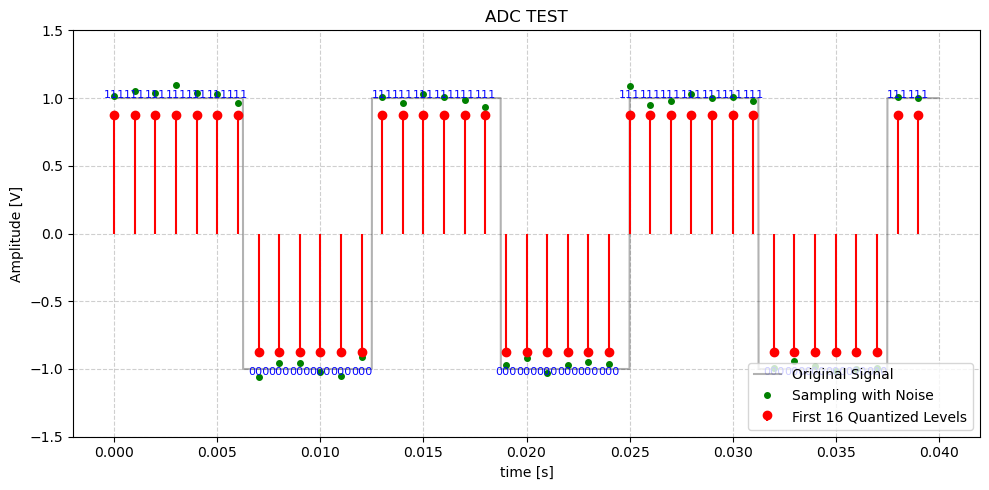

In [734]:
fs_analog_test = 100000 
f_signal_test = 80 # 50 Hz square wave
t_temp = np.linspace(0, 0.04, int(fs_analog_test * 0.04)) # 40 ms duration

#x_analog_test =  np.cos(2 * np.pi * f_signal_test * t_temp) # This will create a cosine wave
x_analog_test = signal.square(2 * np.pi * f_signal_test * t_temp)

# ADC parameters
fs_sample_test = 1000 # 1 kHz sampling rate
bits_test = 3         # 3-bit resolution
v_min_test = -1.0
v_max_test = 1.0
num_execucoes = 10
snr_resultados = []
enob_resultados = []
noise_std_test = 0.05 # Standard deviation of the noise to be added

print(f"Mean results over {num_execucoes} executions with noise:")

for i in range(num_execucoes):
    _, _, _, _, _, snr_run, enob_run = adc_simulation(
        x_analog=x_analog_test, 
        fs_analog=fs_analog_test, 
        fs_sample=fs_sample_test, 
        bits=bits_test, 
        v_min=v_min_test, 
        v_max=v_max_test,
        noise_std=noise_std_test #Noise
    )
    
    # Keep track of results for each run
    snr_resultados.append(snr_run)
    enob_resultados.append(enob_run)

# Finals Means
media_snr = np.mean(snr_resultados)
media_enob = np.mean(enob_resultados)


print("-" * 35)
print(f"ADC Resolution ({bits_test} bits) - Mean of {num_execucoes} runs")
print(f"SNR Real: {media_snr:.2f} dB")
print(f"ENOB Calculate: {media_enob:.2f} bits")
print("-" * 35)

# Run simulation
t_samp, x_samp, x_quant, noise, bits_out, snr_db, enob = adc_simulation(
    x_analog=x_analog_test, 
    fs_analog=fs_analog_test, 
    fs_sample=fs_sample_test, 
    bits=bits_test, 
    v_min=v_min_test, 
    v_max=v_max_test,
    noise_std= noise_std_test # Adding a bit more noise to see the effect on the flat tops
)

# Plot to verify
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_temp, x_analog_test, 'k-', alpha=0.3, label='Original Signal')
#ax.step(t_samp, x_quant, where='post', color='r', label='Saída ADC (Quantizada)')
ax.plot(t_samp, x_samp, 'go', markersize=4, label='Sampling with Noise')
ax.stem(t_samp, x_quant, linefmt='r-', markerfmt='ro', basefmt=' ', label='First 16 Quantized Levels')

# Add text annotations for the first few binary codes
for i in range(40):
    # Adjusting text position slightly based on the signal value
    y_offset = 0.15 if x_quant[i] > 0 else -0.15
    ax.text(t_samp[i], x_quant[i] + y_offset, bits_out[i], fontsize=8, color='blue', ha='center', va='center')

ax.set_title('ADC TEST')
ax.set_xlabel('time [s]')
ax.set_ylabel('Amplitude [V]')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-1.5, 1.5)
plt.tight_layout()
# Print tabular results
df_test = pd.DataFrame({
    'Time [s]': t_samp[:16],
    'Real Sample [V]': x_samp[:16],
    'Quantized [V]': x_quant[:16],
    'Quantization Noise [V]': noise[:16],
    'Binary Code': bits_out[:16]
})
print(df_test.to_markdown(index=False))

Evaluating the ADC for different resolutions...

Bits   | RMS Error (V)   | SNR (dB)     | ENOB
--------------------------------------------------
2      | 0.163356        | 12.73        | 1.82
3      | 0.081918        | 18.72        | 2.82
4      | 0.044027        | 24.11        | 3.71
5      | 0.020151        | 30.90        | 4.84
6      | 0.010479        | 36.58        | 5.78
7      | 0.005141        | 42.77        | 6.81
8      | 0.002199        | 50.14        | 8.04
9      | 0.001052        | 56.55        | 9.10
10     | 0.000584        | 61.66        | 9.95
11     | 0.000287        | 67.83        | 10.97
12     | 0.000140        | 74.06        | 12.01
13     | 0.000070        | 80.13        | 13.02
14     | 0.000034        | 86.43        | 14.06


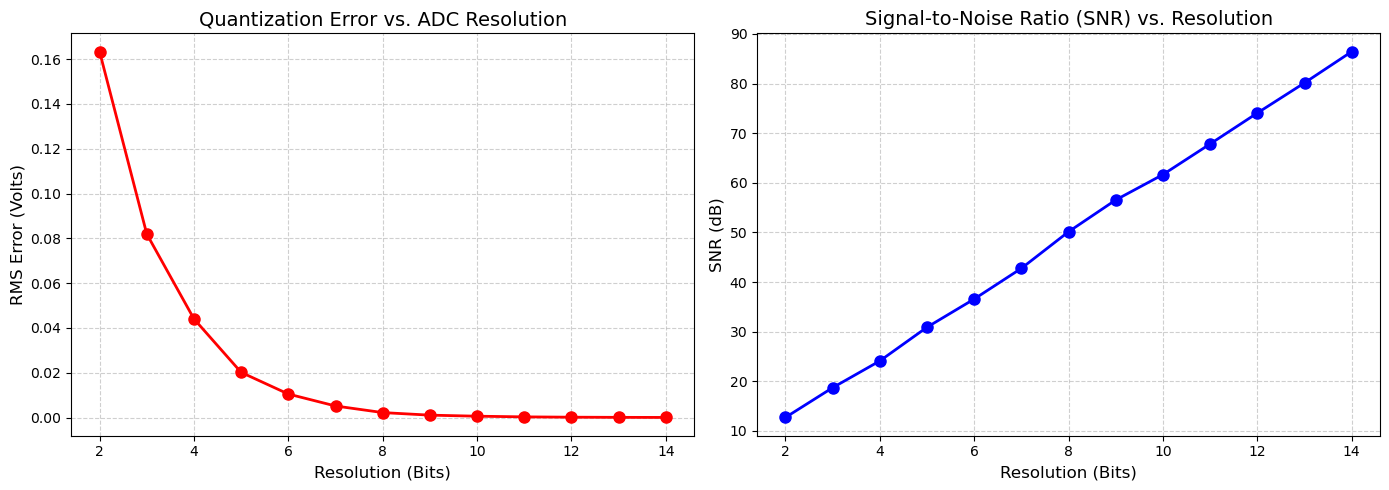

In [699]:
fs_analog_test = 100000 
f_signal_test = 100 # 100 Hz sine wave
t_temp = np.linspace(0, 0.05, int(fs_analog_test * 0.05)) 

# Full-scale sine wave for the ENOB formula to work perfectly
x_analog_test = np.sin(2 * np.pi * f_signal_test * t_temp)

fs_sample_test = 5000 # 5 kHz
v_min_test = -1.0
v_max_test = 1.0

# List of resolutions to test (from 2 to 14 bits)
bit_levels = np.arange(2, 15)

# Lists to store the results
rms_errors = []
snr_results = []
enob_results = []

print("Evaluating the ADC for different resolutions...\n")
print(f"{'Bits':<6} | {'RMS Error (V)':<15} | {'SNR (dB)':<12} | {'ENOB'}")
print("-" * 50)

for bits in bit_levels:
    # Run the simulation for the current resolution (with no additive noise)
    t_samp, x_samp, x_quant, noise, bits_out, snr_db, enob = adc_simulation(
        x_analog=x_analog_test, 
        fs_analog=fs_analog_test, 
        fs_sample=fs_sample_test, 
        bits=bits, 
        v_min=v_min_test, 
        v_max=v_max_test,
        noise_std=0.0 # No external noise to isolate the quantization noise
    )
    
    # Calculate the RMS Error (Square Root of the Mean Noise Power)
    erro_rms = np.sqrt(np.mean(noise**2))
    
    # Store the data
    rms_errors.append(erro_rms)
    snr_results.append(snr_db)
    enob_results.append(enob)
    
    print(f"{bits:<6} | {erro_rms:<15.6f} | {snr_db:<12.2f} | {enob:.2f}")

# --- PLOTTING THE RESULTS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Exponential Drop of the Quantization Error
ax1.plot(bit_levels, rms_errors, 'ro-', linewidth=2, markersize=8)
ax1.set_title('Quantization Error vs. ADC Resolution', fontsize=14)
ax1.set_xlabel('Resolution (Bits)', fontsize=12)
ax1.set_ylabel('RMS Error (Volts)', fontsize=12)
#ax1.set_yscale('log') # Logarithmic scale to see the exponential drop
ax1.grid(True, which="both", ls="--", alpha=0.6)

# Plot 2: SNR Increase
ax2.plot(bit_levels, snr_results, 'bo-', linewidth=2, markersize=8)
ax2.set_title('Signal-to-Noise Ratio (SNR) vs. Resolution', fontsize=14)
ax2.set_xlabel('Resolution (Bits)', fontsize=12)
ax2.set_ylabel('SNR (dB)', fontsize=12)
ax2.grid(True, ls="--", alpha=0.6)

plt.tight_layout()
plt.show()

### *Numba* in ADC
Numba Doesn't Accept Binary Strings as Output. Numba works by translating your Python code into machine code (at the C/C++ level) using a compiler called LLVM. To achieve maximum speed (using the @njit or no-python mode), Numba needs to know the exact data type and memory size of every variable ahead of time.

In [736]:
@njit
def adc_simulation(x_analog, fs_analog, fs_sample, bits, v_min, v_max, noise_std=0.0):
    """
    Simulates the sampling and quantization stages of an ADC.
    Optimized with Numba for high-performance array operations.
    Returns quantized levels as integers instead of binary strings.
    """
    
    # 1. TIME AND SIGNAL PREPARATION
    num_samples = len(x_analog)
    t_final = (num_samples - 1) / fs_analog
    t_analog = np.linspace(0.0, t_final, num_samples)
    
    # Additive White Gaussian Noise (AWGN) Injection
    if noise_std > 0.0:
        noise = np.random.normal(0.0, noise_std, num_samples)
        x_noisy = x_analog + noise
    else:
        x_noisy = x_analog
        
    # 2. SAMPLING
    # Calculate the step size to decimate the analog signal at fs_sample
    step = max(1, int(fs_analog / fs_sample))
    t_sampled = t_analog[::step]
    x_sampled = x_noisy[::step]
    
    # 3. QUANTIZATION
    # Calculate total number of levels (L) and step size (Delta)
    L = 2**bits 
    delta = (v_max - v_min) / L 
    
    # Map samples to level indices (k)
    k = np.floor((x_sampled - v_min) / delta)
    
    # Prevent overload/saturation by clipping indices to valid range [0, L-1]
    k = np.clip(k, 0, L - 1) 
    
    # Calculate reconstructed voltage levels
    x_quantized = v_min + (k + 0.5) * delta
    
    # 4. QUANTIZATION NOISE & INTEGER LEVELS
    quantization_noise = x_sampled - x_quantized
    
    # Convert indices to 64-bit integers for external encoding
    k_int = k.astype(np.int64)
    
    # 5. SNR AND ENOB CALCULATION
    # Calculate average signal power and noise power
    P_signal = np.mean(x_sampled**2)
    P_noise = np.mean(quantization_noise**2)
    
    if P_noise == 0.0:
        snr_db = np.inf
        enob = np.inf
    else:
        # Signal-to-Noise Ratio in dB
        snr_db = 10.0 * np.log10(P_signal / P_noise)
        # Effective Number of Bits
        enob = (snr_db - 1.76) / 6.02
        
    return t_sampled, x_sampled, x_quantized, quantization_noise, k_int, snr_db, enob

def encode_to_binary_strings(k_int, bits):
    """
    Converts an array of integer quantization levels into zero-padded binary strings.
    This runs in standard Python, as Numba is not optimized for string manipulation.
    
    Parameters:
    k_int : Array of integer values representing quantization levels.
    bits  : ADC resolution (used to pad zeros on the left).
    
    Returns:
    List of binary strings (e.g., ['001', '010', '111']).
    """
    # Use native list comprehension for fast Python string formatting
    return [format(val, f'0{bits}b') for val in k_int]

#### Modeling ADC with a knowledge ENOB

In [714]:
def adc_enob_model(x, ENOB, fs, Vmax, Vmin, margin_bits=2):
    """
    Behavioral ADC model based on ENOB specification.

    Parameters
    ----------
    x : ndarray
        Input signal
    ENOB : float
        Effective Number Of Bits
    fs : float
        Sampling frequency (Hz)
    Vmax : float
        Maximum ADC input voltage
    Vmin : float
        Minimum ADC input voltage
    margin_bits : int
        Extra bits used in the internal ideal quantizer

    Returns
    -------
    y : ndarray
        Quantized output signal (with equivalent noise)
    e : ndarray
        Total error (quantization + equivalent noise)
    delta : float
        Quantization step size
    SNR_dB : float
        Measured Signal-to-Noise Ratio (dB)
    Pn : float
        Noise power
    Nbits : int
        Resolution of the internal ideal quantizer (bits)
    """
    # Target SNR from ENOB
    SNR_dB_target = 6.02 * ENOB + 1.76

    Ps = np.mean(x**2)
    Pn_target = Ps / (10**(SNR_dB_target / 10))
    sigma = np.sqrt(Pn_target)

    # Ideal quantizer resolution
    Nbits = int(np.ceil(ENOB)) + margin_bits
    L = 2**Nbits

    delta = (Vmax - Vmin) / L

    # Quantization
    xq = np.round((x - Vmin) / delta) * delta + Vmin

    # Saturation (clipping)
    xq = np.clip(xq, Vmin, Vmax)

    # Equivalent noise (models non-idealities)
    noise = sigma * np.random.randn(len(x))
    y = xq + noise

    # Metrics
    e = x - y

    Ps = np.mean(x**2)
    Pn = np.mean(e**2)

    SNR = Ps / Pn
    SNR_dB = 10 * np.log10(SNR)

    return y, e, delta, SNR_dB, Pn, Nbits

---------------------------------------------
ADC MODELING RESULTS
---------------------------------------------
Target ENOB      : 11.0 bits
Measured SNR     : 68.38 dB
Internal Res.    : 13 bits (Ideal Hardware)
Quantization Step: 0.000244 V
---------------------------------------------


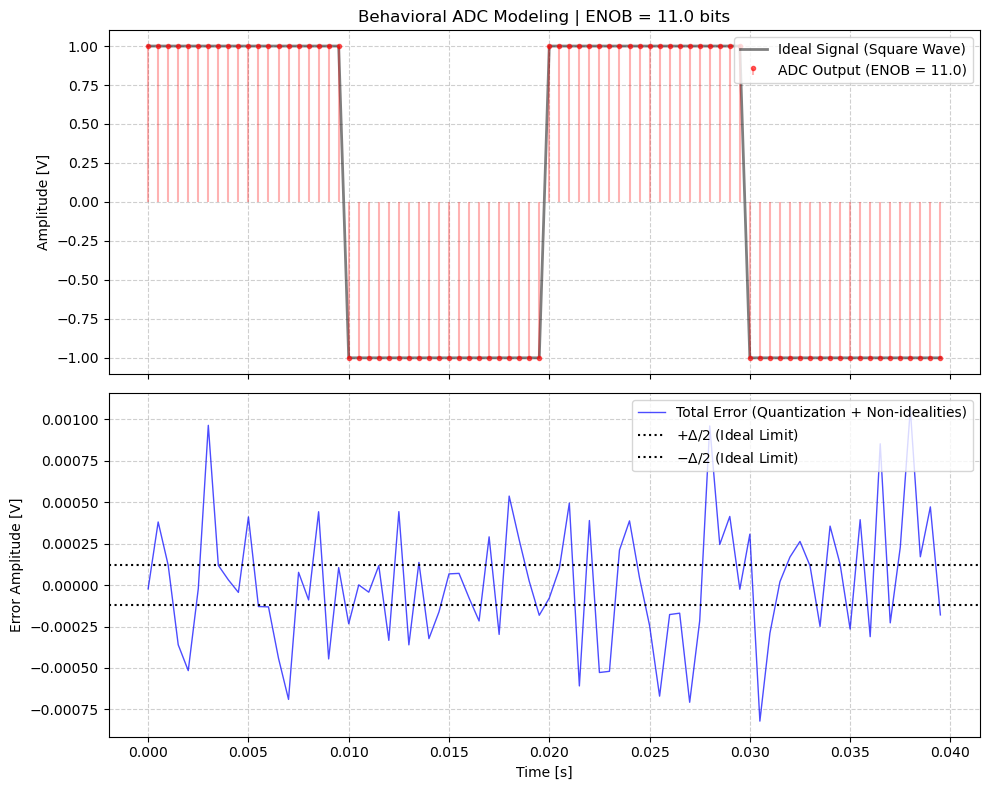

In [718]:
# 1. Analog Signal Configuration (Square Wave)
fs = 2000          # 100 kHz sampling rate
f_sig = 50           # 50 Hz square wave
t = np.arange(0, 0.04, 1/fs) 
x_analog = signal.square(2 * np.pi * f_sig * t)

# 2. Target ADC Specifications
target_enob = 11.0     # 11-bit effective resolution
v_min, v_max = -1.0, 1.0

# 3. Running the Model
y_out, total_error, delta_step, measured_snr, noise_pwr, internal_bits = adc_enob_model(
    x_analog, target_enob, fs, v_max, v_min, margin_bits=2
)

# 4. Printing Results
print("-" * 45)
print("ADC MODELING RESULTS")
print("-" * 45)
print(f"Target ENOB      : {target_enob} bits")
print(f"Measured SNR     : {measured_snr:.2f} dB")
print(f"Internal Res.    : {internal_bits} bits (Ideal Hardware)")
print(f"Quantization Step: {delta_step:.6f} V")
print("-" * 45)

# 5. Graphical Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Signal Plot (Using Stem for ADC output)
ax1.plot(t, x_analog, 'k-', alpha=0.5, lw=2, label='Ideal Signal (Square Wave)')

# Discrete-time representation (Stem)
# Using markerfmt='r.' to avoid cluttering the plot with 4000 dots
markerline, stemlines, baseline = ax1.stem(
    t, y_out, 
    linefmt='r-', 
    markerfmt='r.', 
    basefmt=' ', 
    label=f'ADC Output (ENOB = {target_enob})'
)
# Reducing stem opacity for better visualization
plt.setp(stemlines, 'alpha', 0.3)
plt.setp(markerline, 'alpha', 0.6)

ax1.set_title(f'Behavioral ADC Modeling | ENOB = {target_enob} bits')
ax1.set_ylabel('Amplitude [V]')
ax1.legend(loc='upper right')
ax1.grid(True, ls='--', alpha=0.6)

# Error Plot
ax2.plot(t, total_error, 'b-', lw=1, alpha=0.7, label='Total Error (Quantization + Non-idealities)')
ax2.axhline(delta_step/2, color='k', ls=':', label=r'$+\Delta/2$ (Ideal Limit)')
ax2.axhline(-delta_step/2, color='k', ls=':', label=r'$-\Delta/2$ (Ideal Limit)')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Error Amplitude [V]')
ax2.legend(loc='upper right')
ax2.grid(True, ls='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Lembrar de botasr as saidas em bits do ADC via Enob, Ajustar os textos e explicações para aplicar no relatorio final 

=== COMPARAÇÃO DE SNR: SINAL QUANTIZADO vs ORIGINAL ===

--- Resolução: 2 Bits ---
SNR Teórico Ideal     : 13.80 dB
SNR Simulado (ADC)    : 12.91 dB
--- Resolução: 4 Bits ---
SNR Teórico Ideal     : 25.84 dB
SNR Simulado (ADC)    : 23.93 dB
--- Resolução: 8 Bits ---
SNR Teórico Ideal     : 49.92 dB
SNR Simulado (ADC)    : 48.26 dB
--- Resolução: 12 Bits ---
SNR Teórico Ideal     : 74.00 dB
SNR Simulado (ADC)    : 72.03 dB


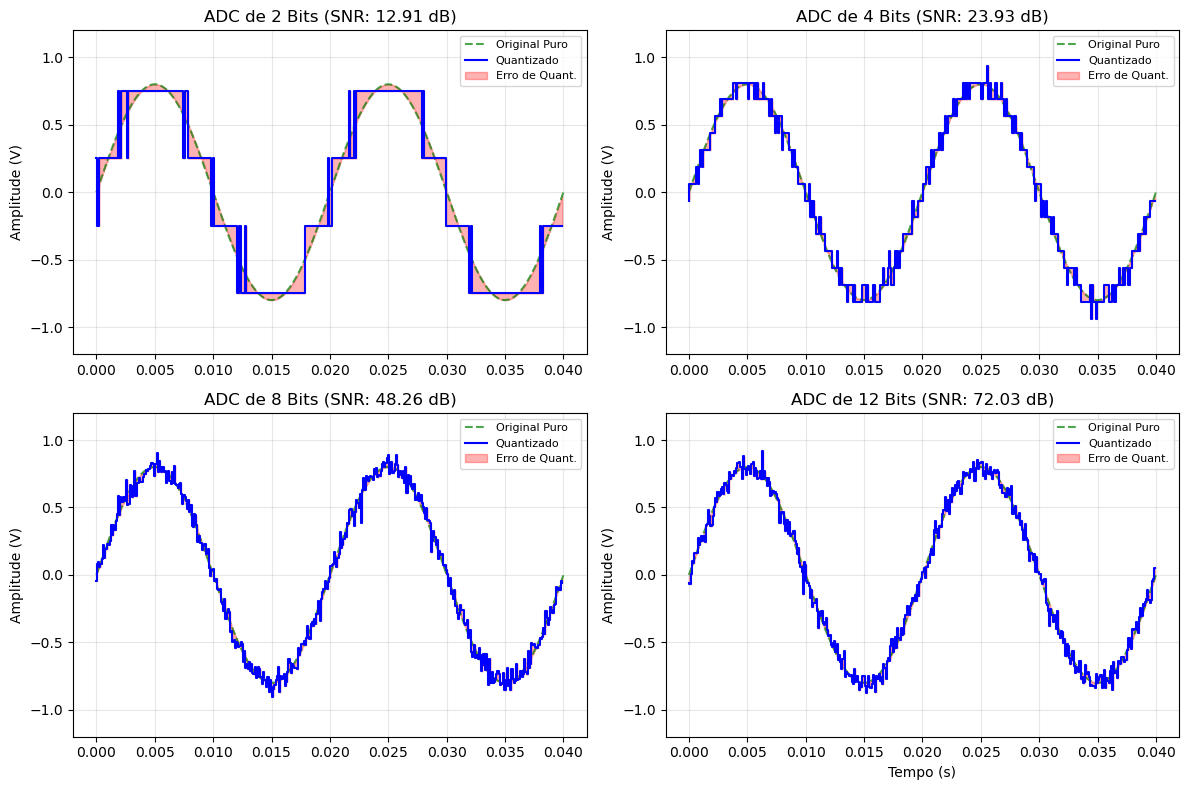

In [749]:
# 1. Parâmetros do Sinal Original (Puro)
fs_analog = 200000  # Frequência base muito alta para simular o contínuo
fs_sample = 10000   # Frequência de amostragem do ADC (10 kHz - bem acima de Nyquist para evitar aliasing)
f_signal = 50       # Onda senoidal de 50 Hz
A = 0.8             # Amplitude máxima de 1V (ocupa toda a faixa do ADC)
v_min, v_max = -1.0, 1.0

# Eixo de tempo e sinal original
t_analog = np.arange(0, 0.04, 1/fs_analog) # 2 ciclos de 50Hz
x_original = A * np.sin(2 * np.pi * f_signal * t_analog)

# Amostramos o sinal original puramente matemático para calcular o erro real depois
step_real = int(fs_analog / fs_sample)
x_original_amostrado = x_original[::step_real]

# 2. Testando diferentes resoluções (bits)
resolucoes = [2, 4, 8, 12]

print("=== COMPARAÇÃO DE SNR: SINAL QUANTIZADO vs ORIGINAL ===\n")

plt.figure(figsize=(12, 8))

for i, bits in enumerate(resolucoes):
    # Simulação sem ruído térmico (noise_std=0) para focar SÓ no erro de quantização
    t_sampled, x_sampled, x_quantized, q_noise, bin_out, snr_simulado, enob = adc_simulation(x_original, fs_analog, fs_sample, bits, v_min, v_max, noise_std=0.05)
    
    # SNR Teórico da Quantização para uma senoide
    snr_teorico = (6.02 * bits) + 1.76
    
    # Calculando o Erro Total (Sinal Original Amostrado - Sinal Quantizado)
    erro_total = x_original_amostrado - x_quantized
    potencia_sinal_original = np.mean(x_original_amostrado**2)
    potencia_erro_total = np.mean(erro_total**2)
    

    
    print(f"--- Resolução: {bits} Bits ---")
    print(f"SNR Teórico Ideal     : {snr_teorico:.2f} dB") # SNR ideal para uma senoide pura
    print(f"SNR Simulado (ADC)    : {snr_simulado:.2f} dB") #já com ruido de quantização
    
    # Plotagem
    plt.subplot(2, 2, i+1)
    plt.plot(t_analog, x_original, 'g--', alpha=0.7, label='Original Puro')
    plt.step(t_sampled, x_quantized, where='mid', color='blue', linewidth=1.5, label='Quantizado')
    
    # Destacando o erro visualmente com preenchimento
    plt.fill_between(t_sampled, x_original_amostrado, x_quantized, color='red', alpha=0.3, step='mid', label='Erro de Quant.')
    
    plt.title(f'ADC de {bits} Bits (SNR: {snr_simulado:.2f} dB)')
    plt.ylabel('Amplitude (V)')
    plt.ylim(-1.2, 1.2)
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, alpha=0.3)

plt.xlabel('Tempo (s)')
plt.tight_layout()

plt.show()

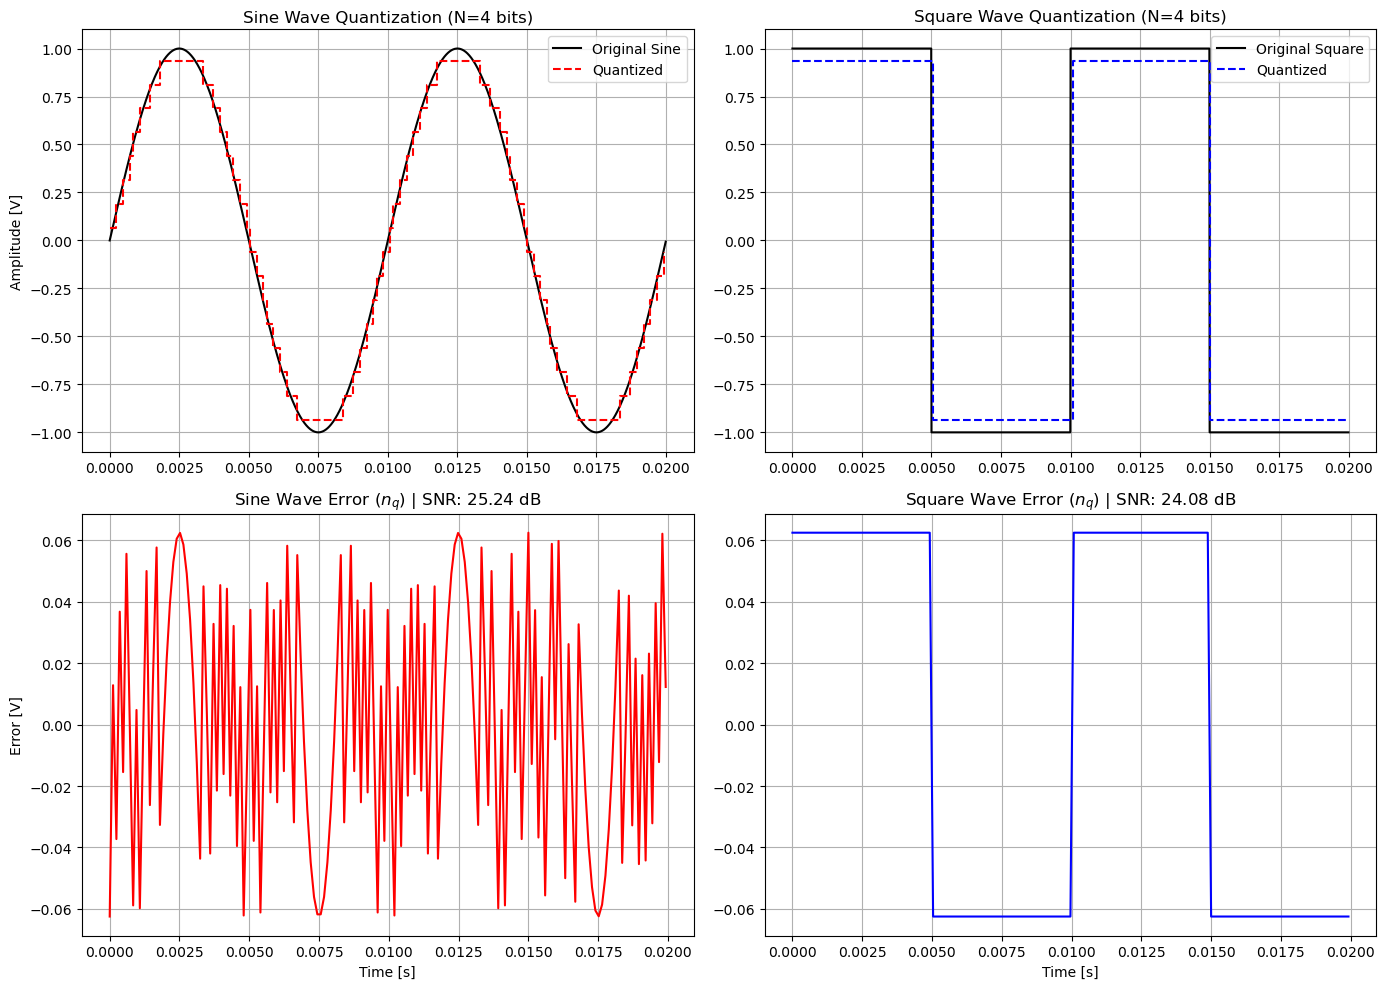

Difference in SNR (Square - Sine): -1.15 dB


In [737]:
fs_analog = 100000 
fs_sample = 8000   
bits = 4           # Lower resolution (4 bits) to make steps visible in plots
v_min = -1.0 
v_max = 1.0  
noise_std = 0.0
f_signal = 100     

t = np.arange(0, 0.02, 1/fs_analog) # 2 periods

# --- Generate Signals ---
x_sine = 1.0 * np.sin(2 * np.pi * f_signal * t)
x_square = 1.0 * signal.square(2 * np.pi * f_signal * t)

# --- ADC Simulation ---
results_sine = adc_simulation(x_sine, fs_analog, fs_sample, bits, v_min, v_max, noise_std)
t_samp_sine, _, x_quant_sine, err_sine, _, snr_sine, enob_sine = results_sine

results_square = adc_simulation(x_square, fs_analog, fs_sample, bits, v_min, v_max, noise_std)
t_samp_sq, _, x_quant_sq, err_sq, _, snr_square, enob_square = results_square

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Sine Wave Quantization
axes[0, 0].plot(t, x_sine, 'k-', label='Original Sine')
axes[0, 0].step(t_samp_sine, x_quant_sine, 'r--', where='post', label='Quantized')
axes[0, 0].set_title(f'Sine Wave Quantization (N={bits} bits)')
axes[0, 0].set_ylabel('Amplitude [V]')
axes[0, 0].grid(True)
axes[0, 0].legend()

# Plot 2: Square Wave Quantization
axes[0, 1].plot(t, x_square, 'k-', label='Original Square')
axes[0, 1].step(t_samp_sq, x_quant_sq, 'b--', where='post', label='Quantized')
axes[0, 1].set_title(f'Square Wave Quantization (N={bits} bits)')
axes[0, 1].grid(True)
axes[0, 1].legend()

# Plot 3: Sine Wave Error
axes[1, 0].plot(t_samp_sine, err_sine, 'r-')
axes[1, 0].set_title(f'Sine Wave Error ($n_q$) | SNR: {snr_sine:.2f} dB')
axes[1, 0].set_xlabel('Time [s]')
axes[1, 0].set_ylabel('Error [V]')
axes[1, 0].grid(True)

# Plot 4: Square Wave Error
axes[1, 1].plot(t_samp_sq, err_sq, 'b-')
axes[1, 1].set_title(f'Square Wave Error ($n_q$) | SNR: {snr_square:.2f} dB')
axes[1, 1].set_xlabel('Time [s]')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# --- Print Final Results ---
print(f"Difference in SNR (Square - Sine): {snr_square - snr_sine:.2f} dB")